# Polynomial Regression

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muhammadtalhaishtiaq/ai-orchestrator/blob/main/02-regression/03_polynomial_regression.ipynb)

**Time**: ~20 minutes

## What You'll Learn
- Beyond straight lines: curves!
- Polynomial degree selection
- Overfitting risk
- When to use polynomial regression

## Why This Matters

Not all relationships are linear!

**Example:** Salary vs Years of Experience
```
Year 1:  $30k
Year 5:  $60k  (steep growth)
Year 10: $90k  (slower growth)
Year 20: $100k (plateau)
```

**Linear fit**: Terrible
**Polynomial fit**: Perfect! (Captures the curve)

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)
print("Polynomial Regression: Fitting Curves to Data")

Polynomial Regression: Fitting Curves to Data


---
## 1. Create Non-Linear Data

Experience vs Salary:
    Years      Salary
0       1   21.490142
1       2   27.869478
2       3   36.584082
3       4   44.569090
4       5   44.018899
5       6   48.287384
6       7   57.652665
7       8   58.870847
8       9   58.591577
9      10   64.873233
10     15   76.069414
11     20   88.045530
12     25  100.725887
13     30  103.804671


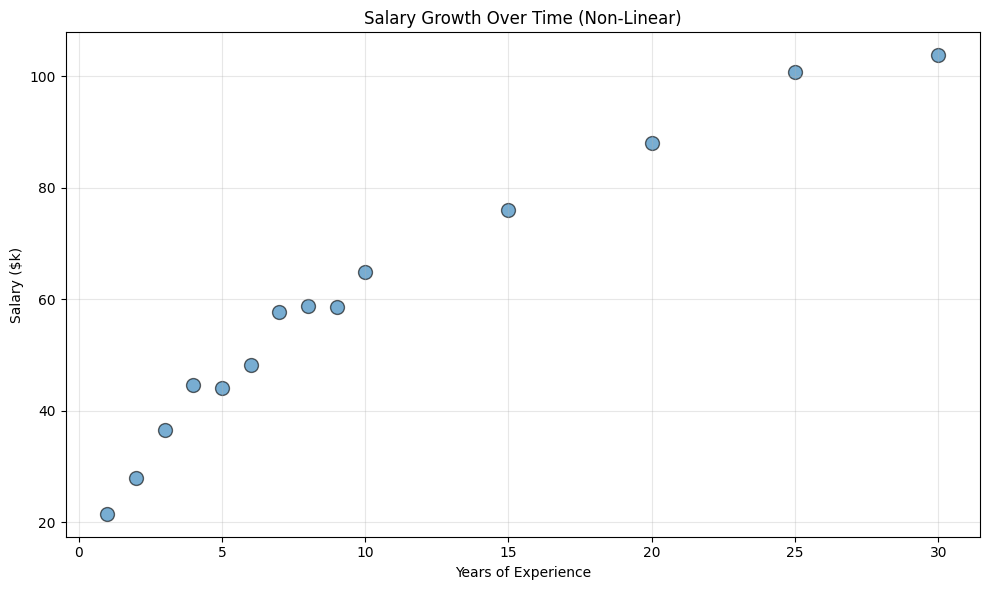

Notice: Data is curved, not a straight line!


In [8]:
# Years vs salary (non-linear)
X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
              15, 20, 25, 30]).reshape(-1, 1)

# True relationship: sqrt(years) with noise
y = 20 * np.sqrt(X.flatten()) + np.random.normal(0, 3, len(X))

df = pd.DataFrame({'Years': X.flatten(), 'Salary': y})
print("Experience vs Salary:")
print(df)

# Visualize
plt.figure(figsize=(10, 6))
plt.scatter(X, y, s=100, alpha=0.6, edgecolors='black')
plt.xlabel('Years of Experience')
plt.ylabel('Salary ($k)')
plt.title('Salary Growth Over Time (Non-Linear)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Notice: Data is curved, not a straight line!")

---
## 2. Compare Linear vs Polynomial

In [9]:
# Linear fit
model_linear = LinearRegression()
model_linear.fit(X, y)
y_pred_linear = model_linear.predict(X)
r2_linear = r2_score(y, y_pred_linear)

# Polynomial fit (degree 2)
poly_features = PolynomialFeatures(degree=2)
X_poly = poly_features.fit_transform(X)
model_poly2 = LinearRegression()
model_poly2.fit(X_poly, y)
y_pred_poly2 = model_poly2.predict(X_poly)
r2_poly2 = r2_score(y, y_pred_poly2)

# Polynomial fit (degree 3)
poly_features3 = PolynomialFeatures(degree=3)
X_poly3 = poly_features3.fit_transform(X)
model_poly3 = LinearRegression()
model_poly3.fit(X_poly3, y)
y_pred_poly3 = model_poly3.predict(X_poly3)
r2_poly3 = r2_score(y, y_pred_poly3)

print("Model Comparison:")
print(f"  Linear (R²={r2_linear:.4f}): y = {model_linear.coef_[0]:.4f}x + {model_linear.intercept_:.4f}")
print(f"  Polynomial degree 2 (R²={r2_poly2:.4f}): Better fit!")
print(f"  Polynomial degree 3 (R²={r2_poly3:.4f}): Even better")

Model Comparison:
  Linear (R²=0.9411): y = 2.7569x + 30.8363
  Polynomial degree 2 (R²=0.9868): Better fit!
  Polynomial degree 3 (R²=0.9905): Even better


---
## 3. Visualize Fits

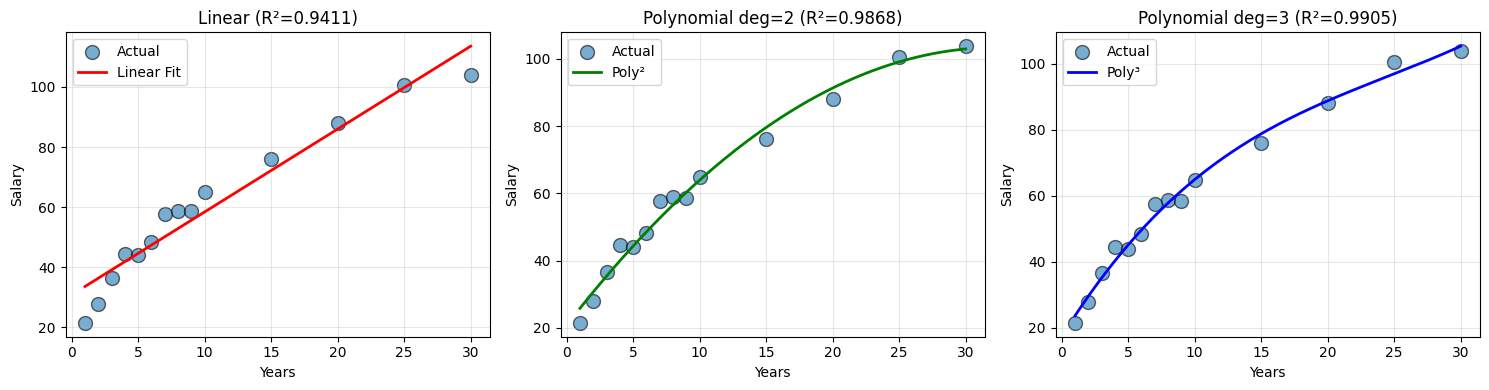

✅ Polynomial fits the data MUCH better!


In [10]:
# Create smooth lines for plotting
X_smooth = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Linear
y_smooth_linear = model_linear.predict(X_smooth)
axes[0].scatter(X, y, s=100, alpha=0.6, edgecolors='black', label='Actual')
axes[0].plot(X_smooth, y_smooth_linear, 'r-', linewidth=2, label='Linear Fit')
axes[0].set_title(f'Linear (R²={r2_linear:.4f})')
axes[0].set_xlabel('Years')
axes[0].set_ylabel('Salary')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Polynomial degree 2
X_smooth_poly = poly_features.transform(X_smooth)
y_smooth_poly2 = model_poly2.predict(X_smooth_poly)
axes[1].scatter(X, y, s=100, alpha=0.6, edgecolors='black', label='Actual')
axes[1].plot(X_smooth, y_smooth_poly2, 'g-', linewidth=2, label='Poly²')
axes[1].set_title(f'Polynomial deg=2 (R²={r2_poly2:.4f})')
axes[1].set_xlabel('Years')
axes[1].set_ylabel('Salary')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Polynomial degree 3
X_smooth_poly3 = poly_features3.transform(X_smooth)
y_smooth_poly3 = model_poly3.predict(X_smooth_poly3)
axes[2].scatter(X, y, s=100, alpha=0.6, edgecolors='black', label='Actual')
axes[2].plot(X_smooth, y_smooth_poly3, 'b-', linewidth=2, label='Poly³')
axes[2].set_title(f'Polynomial deg=3 (R²={r2_poly3:.4f})')
axes[2].set_xlabel('Years')
axes[2].set_ylabel('Salary')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Polynomial fits the data MUCH better!")

---
## 4. Polynomial Features

In [11]:
# See what PolynomialFeatures creates
print("Original feature:")
print(X[:5].flatten())

poly = PolynomialFeatures(degree=2)
X_poly_demo = poly.fit_transform(X[:5])

print("\nPolynomial features (degree 2):")
print(X_poly_demo)

print("\nColumns: [1, x, x²]")
print("So it becomes a LINEAR regression with engineered features!")
print("\nFormula:")
print("y = β₀ + β₁x + β₂x² + ε  (still linear in parameters!)")

Original feature:
[1 2 3 4 5]

Polynomial features (degree 2):
[[ 1.  1.  1.]
 [ 1.  2.  4.]
 [ 1.  3.  9.]
 [ 1.  4. 16.]
 [ 1.  5. 25.]]

Columns: [1, x, x²]
So it becomes a LINEAR regression with engineered features!

Formula:
y = β₀ + β₁x + β₂x² + ε  (still linear in parameters!)


---
## 5. Choosing the Right Degree

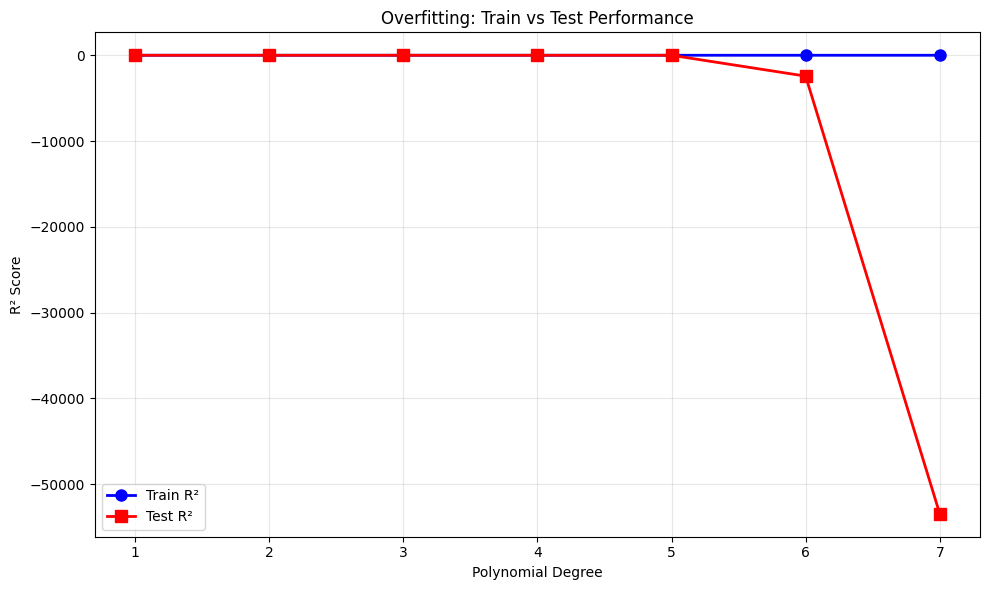

Degree Selection Tips:
  1. Find sweet spot: When test R² is high, train ≈ test
  2. Avoid high degrees: Risk of overfitting
  3. Start low, increase until test performance plateaus

⚠️ Notice: High degrees = train goes up, test goes down
           That's OVERFITTING!


In [12]:
# Test different degrees
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

degrees = range(1, 8)
train_r2s = []
test_r2s = []

for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    train_r2 = model.score(X_train_poly, y_train)
    test_r2 = model.score(X_test_poly, y_test)
    
    train_r2s.append(train_r2)
    test_r2s.append(test_r2)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(degrees, train_r2s, 'b-o', linewidth=2, markersize=8, label='Train R²')
plt.plot(degrees, test_r2s, 'r-s', linewidth=2, markersize=8, label='Test R²')
plt.xlabel('Polynomial Degree')
plt.ylabel('R² Score')
plt.title('Overfitting: Train vs Test Performance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Degree Selection Tips:")
print("  1. Find sweet spot: When test R² is high, train ≈ test")
print("  2. Avoid high degrees: Risk of overfitting")
print("  3. Start low, increase until test performance plateaus")
print("\n⚠️ Notice: High degrees = train goes up, test goes down")
print("           That's OVERFITTING!")

---
## 6. When to Use Polynomial

In [13]:
print("✅ USE Polynomial Regression when:")
print("  - Relationship is curved (non-linear)")
print("  - R² improves significantly over linear")
print("  - Domain knowledge suggests polynomial")
print("\n❌ DON'T USE when:")
print("  - Linear fit is already good (Occam's Razor)")
print("  - High degree needed (risk overfitting)")
print("  - Only 1 feature (try other models instead)")
print("\n💡 Alternatives:")
print("  - Decision Trees (better for complex patterns)")
print("  - Splines (locally polynomial)")
print("  - Gaussian Process (flexible)")

✅ USE Polynomial Regression when:
  - Relationship is curved (non-linear)
  - R² improves significantly over linear
  - Domain knowledge suggests polynomial

❌ DON'T USE when:
  - Linear fit is already good (Occam's Razor)
  - High degree needed (risk overfitting)
  - Only 1 feature (try other models instead)

💡 Alternatives:
  - Decision Trees (better for complex patterns)
  - Splines (locally polynomial)
  - Gaussian Process (flexible)


---
## Key Takeaways

1. **Not all data is linear**: Use polynomial for curves
2. **Feature engineering**: x² and x³ from single x
3. **Still uses LinearRegression**: It's engineered features
4. **Check overfitting**: Monitor train vs test R²
5. **Start low, go high**: Degree 2-3 usually enough
6. **Watch the gap**: If train>>test, you've overfit

Simple but powerful for non-linear relationships!

---
## Your Turn

1. Generate non-linear data (e.g., y = sin(x) + noise)
2. Try degrees 1-5
3. Plot actual vs each fit
4. Compare R² scores
5. Identify best degree

In [14]:
# Your code here